In [31]:
# GENERAL LIBRARIES
import numpy as np
import pandas as pd
import pennylane as qml
# from pennylane.devices import DefaultQubit, QubitDevice
# from pennylane.operation import Tensor, Operation
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report)

# TORCH MODULES
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler

# Plot parameters
plt.rcParams.update({
    'lines.linewidth': 2,               # linewidth
    'mathtext.fontset': 'cm',           # math font
    'mathtext.default': 'it',           # math font style
    'font.size': 24,                    # font size
    'axes.titlesize': 24,               # title size
    'axes.grid': True,                  # grid
    'grid.linestyle': '-.',             # grid style
    'axes.facecolor': '#ECECEC',        # background color for the axes
    'figure.facecolor': '#FFFFFF',      # background color for the axes
    'legend.facecolor': '#FFFFFF'       # background color for the legend
})

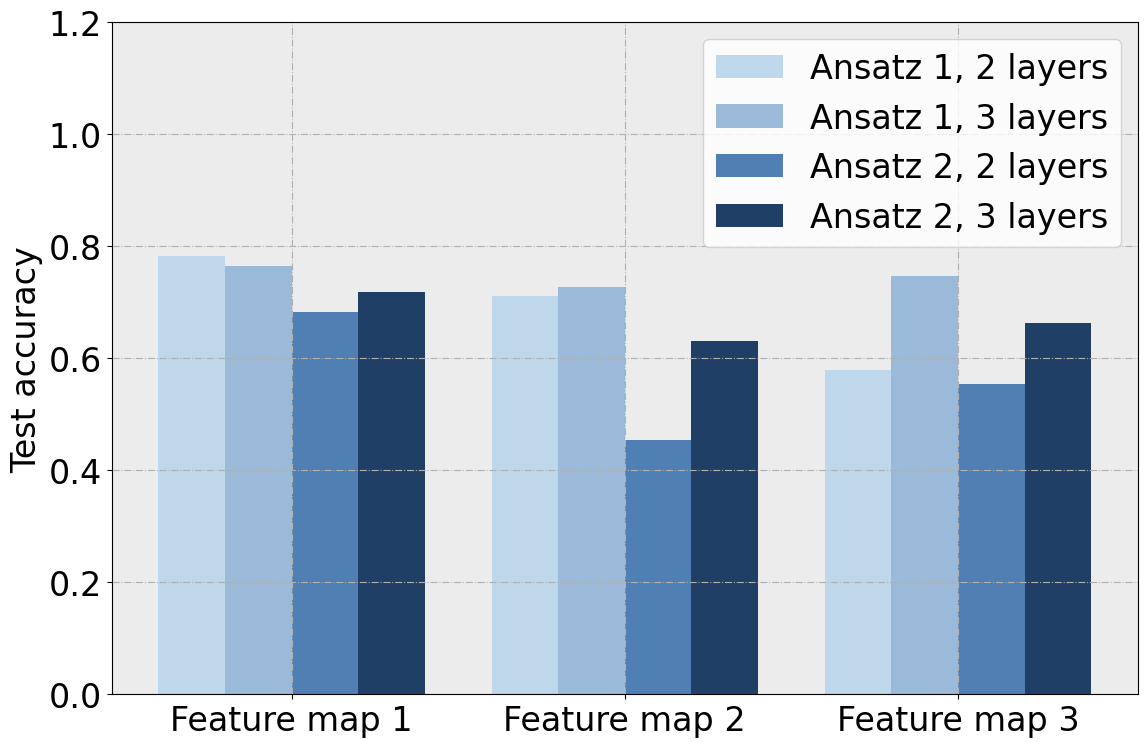

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Feature maps
feature_maps = ["Feature map 1", "Feature map 2", "Feature map 3"]
x = np.arange(len(feature_maps))

# Bar width
width = 0.2

# Mock accuracies (replace with real values later)
# Shape: [feature_map]
ans1_l2 = [0.7831, 0.7105, 0.5793]
ans1_l3 = [0.7641, 0.7262, 0.7460]
ans2_l2 = [0.6830, 0.4541, 0.5532]
ans2_l3 = [0.7184, 0.6314, 0.6626]

# Create figure
fig, ax = plt.subplots(figsize = (12, 8))

# Shades of blue (light → dark)
colors = [
    "#BFD7EA",  # light blue
    "#9BB9D9",
    "#4F7FB3",
    "#1F3F66"   # dark blue
]

# Plot bars
ax.bar(x - 1.5 * width, ans1_l2, width, label = "Ansatz 1, 2 layers", color = colors[0])
ax.bar(x - 0.5 * width, ans1_l3, width, label = "Ansatz 1, 3 layers", color = colors[1])
ax.bar(x + 0.5 * width, ans2_l2, width, label = "Ansatz 2, 2 layers", color = colors[2])
ax.bar(x + 1.5 * width, ans2_l3, width, label = "Ansatz 2, 3 layers", color = colors[3])

# Labels and formatting
ax.set_ylabel("Test accuracy")
# ax.set_xlabel("Feature map")
ax.set_xticks(x)
ax.set_xticklabels(feature_maps)
ax.set_ylim(0.0, 1.2)

# ax.set_title("Test accuracy for different Feature Maps and Ansatz Configurations")
ax.legend(frameon = True)#, loc = "lower left")

plt.tight_layout()
plt.savefig("results.pdf")


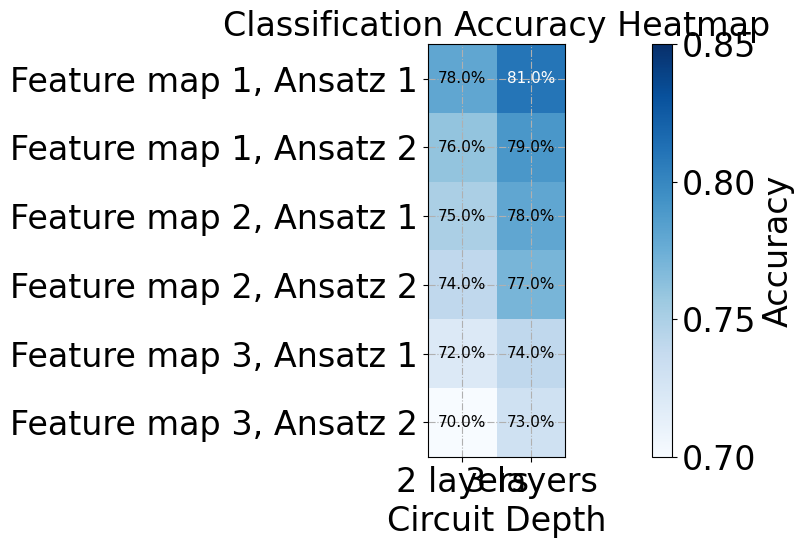

In [33]:
# Row labels: Feature Map + Ansatz
rows = [
    "Feature map 1, Ansatz 1",
    "Feature map 1, Ansatz 2",
    "Feature map 2, Ansatz 1",
    "Feature map 2, Ansatz 2",
    "Feature map 3, Ansatz 1",
    "Feature map 3, Ansatz 2",
]

# Column labels: layers
cols = ["2 layers", "3 layers"]

# Mock accuracy data
# Shape: (6 rows, 2 columns)
accuracy = np.array([
    [0.78, 0.81],  # FM1 - Ansatz 1
    [0.76, 0.79],  # FM1 - Ansatz 2
    [0.75, 0.78],  # FM2 - Ansatz 1
    [0.74, 0.77],  # FM2 - Ansatz 2
    [0.72, 0.74],  # FM3 - Ansatz 1
    [0.70, 0.73],  # FM3 - Ansatz 2
])

# Create figure
fig, ax = plt.subplots(figsize=(18, 6))

# Plot heatmap
im = ax.imshow(accuracy, cmap="Blues", vmin=0.70, vmax=0.85)

# Axis labels
ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(rows)))
ax.set_xticklabels(cols)
ax.set_yticklabels(rows)

ax.set_xlabel("Circuit Depth")
ax.set_title("Classification Accuracy Heatmap")

# Add text annotations
for i in range(len(rows)):
    for j in range(len(cols)):
        ax.text(
            j, i,
            f"{accuracy[i, j]*100:.1f}%",
            ha="center", va="center",
            color="black" if accuracy[i, j] < 0.80 else "white",
            fontsize=11
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Accuracy")

plt.tight_layout()
plt.show()


Here, we define the global variables: device (cpu or CUDA), seed (for debugging), and the number of qubits (one for each feature, in our case, five qubits).

In [34]:
# GLOBAL VARIABLES
DEVICE = 'cpu'
SEED = 42
QUBITS = 5

We upload the data we will use for the binary classification task. For that, we chose five numerical features `est_diameter_min`, `est_diameter_max`, `relative_velocity`, `miss_distance`, and `absolute_magnitude`. The target was the column `hazardous`.

In [35]:
# Data uploading
class NasaDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        data = torch.tensor(self.data[index], dtype = torch.float32)
        targets = torch.tensor(self.targets[index], dtype = torch.float32)
        return data, targets

# Raw data
raw_data = pd.read_csv(r"neo.csv")

# Relevant features
feats = [
    "est_diameter_min",
    "est_diameter_max",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude",
]

data = raw_data[feats].values.astype(np.float32)
targets = raw_data["hazardous"].values.astype(np.float32)

Next, we split the data into training data, testing data, and validation data. For that, we used the modules provided by `sklearn`. 

In [36]:
# Training data
data_tr, data_temp, targets_tr, targets_temp = train_test_split(
    data, targets, test_size = 0.3, random_state = SEED, stratify = targets)

# Validation and testing data
data_val, data_test, targets_val, targets_test = train_test_split(
    data_temp, targets_temp, test_size = 0.5, random_state = SEED, stratify = targets_temp)

# Scale data
scaler = StandardScaler()
data_tr = scaler.fit_transform(data_tr).astype(np.float32)
data_val = scaler.transform(data_val).astype(np.float32)
data_test = scaler.transform(data_test).astype(np.float32)

# Datasets
train_ds = NasaDataset(data_tr, targets_tr)
val_ds = NasaDataset(data_val, targets_val)
test_ds = NasaDataset(data_test, targets_test)

In [37]:
print(f"Dataset sizes:")
print(f"-  Train: {len(train_ds)} samples")
print(f"-  Val:   {len(val_ds)} samples")
print(f"-  Test:  {len(test_ds)} samples\n")

Dataset sizes:
-  Train: 63585 samples
-  Val:   13625 samples
-  Test:  13626 samples



In [38]:
def create_dataloaders(batch_size: int = 32):
    targets = torch.tensor(train_ds.targets, dtype = torch.long)
    
    class_counts = torch.bincount(targets)
    class_weights = 1.0 / class_counts.float()
    sample_weights = class_weights[targets]

    sampler = WeightedRandomSampler(
        weights = sample_weights,
        num_samples = len(sample_weights),
        replacement = True)

    train_loader = DataLoader(
        train_ds,
        batch_size = batch_size,
        sampler = sampler)

    val_loader = DataLoader(
        val_ds,
        batch_size = batch_size,
        shuffle = False)

    test_loader = DataLoader(
        test_ds,
        batch_size = batch_size,
        shuffle = False)

    print(f"DataLoader info (batch_size = {batch_size}):")
    print(f"  - Train batches: {len(train_loader)}")
    print(f"  - Val batches: {len(val_loader)}")
    print(f"  - Test batches: {len(test_loader)}\n")

    return train_loader, val_loader, test_loader

In [39]:
train_loader, val_loader, test_loader = create_dataloaders(batch_size = 64)

DataLoader info (batch_size = 64):
  - Train batches: 994
  - Val batches: 213
  - Test batches: 213



Here, we construct the quantum neural network. For that, we recall that we want to learn a function 
$$
f_{\boldsymbol{\theta}}(\vec{x}) = \langle 0 | \hat{U}^{\dagger}(\vec{x}) \hat{W}^{\dagger}(\boldsymbol{\theta}) \hat{O} \hat{W}(\boldsymbol{\theta}) \hat{U}(\vec{x}) | 0 \rangle
$$

that classifies a data point into one of two categories. Here, $\hat{U}(\vec{x})$ is a data encoding quantum circuit (or feature map) that maps the classical data into a quantum state. For our project, we used three different data encoding quantum circuits:
$$
\begin{align*}
    %
    \hat{U}_{1}(\vec{x}) &= \bigotimes_{j = 0}^{4} \hat{R}_{y}(x_{j}), \\
    %
    \hat{U}_{2}(\vec{x}) &= \left[ \bigotimes_{j = 0}^{4} \hat{R}_{x}(x_{j}) \right] \left[ \bigotimes_{j = 0}^{4} \hat{R}_{z}(x_{j}) \right], \\
    %
    \hat{U}_{3}(\vec{x}) &= \prod_{r = 1}^{R} \left[ \left( \prod_{0 \leq j < k \leq 4} \mathrm{e}^{-\mathrm{i} x_{j} x_{k} Z_{j} Z_{k}} \right) \left( \bigotimes_{j = 0}^{4} \hat{R}_{z}(2 x_{j}) \right) \left( \bigotimes_{j = 0}^{4} \hat{H}_{j} \right) \right].
\end{align*}
$$

Here, $\hat{R}$ represents a rotation gate, and $r$ is the number of repetions. We used $r = 2$, as the authors from the original paper did. Furthermore, we implemented three different ansatze:
$$
\begin{align*}
    %
    \hat{W}_{1}(\boldsymbol{\theta}) &= \prod_{\ell = 1}^{L} \left[ \left( \prod_{j = 0}^{4} \mathrm{CNOT}_{j, j + 1} \right) \left( \bigotimes_{j = 0}^{4} \hat{R}_{y}(\theta_{\ell, j}) \right) \right], \\
    %
    \hat{W}_{2}(\boldsymbol{\theta}) &= \prod_{\ell = 1}^{L} \left[ \left( \prod_{j = 0}^{4} \mathrm{CNOT}_{j, j + 1} \right) \left( \bigotimes_{j = 0}^{4} \hat{R}_{z}(\theta_{\ell, j}) \hat{R}_{x}(\theta_{\ell, j}) \right) \right].
\end{align*}
$$

$L$ represents the number of layers (that is, the number of repetitions of the same block of quantum gates).

In [40]:
# Feature maps or data encoding circuits
def feature_map_1(data, n_qubits, scale = 1.0):
    qml.AngleEmbedding(features = data * scale, wires = range(n_qubits), rotation = 'Y')

def feature_map_2(data, n_qubits, scale = 1.0):
    qml.AngleEmbedding(features = data * scale, wires = range(n_qubits), rotation = 'Z')
    qml.AngleEmbedding(features = data * scale, wires = range(n_qubits), rotation = 'X')

def feature_map_3(data, n_qubits, reps = 2):
    assert len(data) == n_qubits, f"Input size {len(data)} must match n_qubits {n_qubits}"
    for _ in range(reps):
        for index in range(n_qubits):
            qml.Hadamard(wires = index)

        for index in range(n_qubits):
            qml.RZ(2.0 * data[index], wires = index)

        for idx0 in range(n_qubits):
            for idx1 in range(idx0 + 1, n_qubits):
                qml.CNOT(wires = [idx0, idx1])
                qml.RZ(2.0 * data[idx0] * data[idx1], wires = idx1)
                qml.CNOT(wires = [idx0, idx1])

# Variational ansatze
def variational_ansatz_1(angle, n_qubits):
    n_layers, n_wires = angle.shape
    assert n_wires == n_qubits, f"Expected {n_qubits} wires, got {n_wires}"
    
    for layer in range(n_layers):
        for qubit in range(n_wires):
            qml.RY(phi = angle[layer, qubit], wires = qubit)
        for qubit in range(n_wires):
            qml.CNOT(wires = [qubit, (qubit + 1) % n_wires])

def variational_ansatz_2(angle, n_qubits):
    n_layers, n_wires = angle.shape
    assert n_wires == n_qubits, f"Expected {n_qubits} wires, got {n_wires}"
    
    for layer in range(n_layers):
        for qubit in range(n_wires):
            qml.RX(angle[layer, qubit], wires = qubit)
            qml.RZ(angle[layer, qubit], wires = qubit)
        for qubit in range(n_wires - 1, -1, -1):
            qml.CNOT(wires = [(qubit + 1) % n_wires, qubit])

def variational_ansatz_3(angle, n_qubits):
    n_layers, n_params = angle.shape
    assert n_params == 20, f"Each layer requires 20 parameters, got {n_params}"
    assert n_qubits == 5, "This ansatz is designed for 5 qubits"
    
    for layer in range(n_layers):
        idx = 0
        params = angle[layer]
        
        # First RY layer
        for qubit in range(n_qubits):
            qml.RY(params[idx], wires = qubit)
            idx += 1
        
        # CRZ: 4 -> 0
        qml.CRZ(params[idx], wires = [4, 0])
        idx += 1
        
        # CRZ chain
        crz_pairs_step3 = [(3, 4), (2, 3), (2, 1), (0, 1)]
        for control, target in crz_pairs_step3:
            qml.CRZ(params[idx], wires = [control, target])
            idx += 1
        
        # Second RY layer
        for qubit in range(n_qubits):
            qml.RY(params[idx], wires = qubit)
            idx += 1
        
        # Final CRZ layer
        crz_pairs_step5 = [(4, 3), (0, 4), (1, 0), (2, 1), (3, 2)]
        for control, target in crz_pairs_step5:
            qml.CRZ(params[idx], wires = [control, target])
            idx += 1

In [41]:
FEATURE_MAPS = {
    "fm1": feature_map_1,
    "fm2": feature_map_2,
    "fm3": feature_map_3}

ANSATZE = {
    "ansatz1": variational_ansatz_1,
    "ansatz2": variational_ansatz_2,
    "ansatz3": variational_ansatz_3}

In [42]:
class QNNClassifier(nn.Module):
    def __init__(self, angle_shape, feature_map_name = "fm1", ansatz_name = "ansatz1", n_qubits = QUBITS):
        super().__init__()
        self.angle = nn.Parameter(torch.randn(angle_shape, dtype = torch.float32) * 0.01)
        self.n_qubits = n_qubits
        
        dev = qml.device("lightning.qubit", wires = n_qubits)
        @qml.qnode(dev, interface = "torch", diff_method = "adjoint")
        def circuit(data, angle):
            feature_map = FEATURE_MAPS[feature_map_name]
            ansatz = ANSATZE[ansatz_name]
            
            if feature_map_name == "fm3" and data.ndim > 1:
                for _ in range(2):
                    for index in range(n_qubits):
                        qml.Hadamard(wires = index)
                    for index in range(n_qubits):
                        qml.RZ(2.0 * data[:, index], wires = index)
                    for idx0 in range(n_qubits):
                        for idx1 in range(idx0 + 1, n_qubits):
                            qml.CNOT(wires = [idx0, idx1])
                            qml.RZ(2.0 * data[:, idx0] * data[:, idx1], wires = idx1)
                            qml.CNOT(wires = [idx0, idx1])
            else:
                feature_map(data, n_qubits = n_qubits)
            ansatz(angle, n_qubits)
            return qml.expval(qml.PauliZ(0))
        self.circuit = circuit

    def forward(self, data):
        data = data.to(torch.float32)
        expvals = self.circuit(data, self.angle)
        probabilities = (expvals + torch.tensor(1.0, dtype = torch.float32)) / torch.tensor(2.0, dtype = torch.float32)

        if probabilities.ndim == 1:
            return probabilities.unsqueeze(1)
        return probabilities

In [ ]:
def train_and_evaluate(qnn, 
                       train_loader,
                       val_loader,
                       test_loader,
                       n_epochs = 50,
                       n_batches = None,
                       device = DEVICE, 
                       min_learn_rate = 1e-3,
                       max_learn_rate = 1e-1,
                       feature_map_name = "fm1",
                       ansatz_name = "ansatz1"):

    qnn = qnn.to(device)

    total_train_batches = len(train_loader)
    batches_per_epoch = n_batches if n_batches is not None else total_train_batches
    optimizer = torch.optim.Adam(qnn.parameters(), lr = min_learn_rate)

    scheduler = torch.optim.lr_scheduler.CyclicLR(
        optimizer,
        base_lr = min_learn_rate,
        max_lr = max_learn_rate,
        step_size_up = batches_per_epoch // 2,
        mode = "triangular",
        cycle_momentum = False
    )

    loss_function = nn.BCELoss()
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []}
    
    # Determine batches per epoch
    total_train_batches = len(train_loader)
    batches_per_epoch = n_batches if n_batches is not None else total_train_batches
    
    print(f"Training Configuration:")
    print(f"  1. Feature map: {feature_map_name}")
    print(f"  2. Ansatz: {ansatz_name}")
    print(f"  3. Learning rate range: [{min_learn_rate}, {max_learn_rate}]")
    print(f"  4. Device: {device}")
    print(f"  5. Total train batches available: {total_train_batches}")
    print(f"  6. Batches per epoch: {batches_per_epoch}")
    print(f"  7. Epochs: {n_epochs}\n")
    
    # Training loop
    for epoch in range(n_epochs):
        # Training phase
        qnn.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        pbar = tqdm(enumerate(train_loader), 
                   total = batches_per_epoch,
                   desc = f"Epoch {epoch + 1}/{n_epochs} [Train]",
                   leave = True)
        
        for batch_idx, (data, targets) in pbar:
            if batch_idx >= batches_per_epoch:
                break
                
            data, targets = data.to(device), targets.to(device)
            targets = targets.to(torch.float32).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = qnn(data)
            loss = loss_function(outputs, targets)
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            predictions = (outputs > 0.5).float()
            train_correct += (predictions == targets).sum().item()
            train_total += targets.size(0)
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.0 * train_correct / train_total:.2f}%'
            })
        
        pbar.close()
        
        # VALIDATION PHASE
        qnn.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for data, targets in tqdm(val_loader, 
                                       desc = f"Epoch {epoch + 1}/{n_epochs} [Val]  ",
                                       leave = True):
                data, targets = data.to(device), targets.to(device)
                targets = targets.to(torch.float32).unsqueeze(1)
                
                outputs = qnn(data)
                loss = loss_function(outputs, targets)
                
                val_loss += loss.item()
                predictions = (outputs > 0.5).float()
                val_correct += (predictions == targets).sum().item()
                val_total += targets.size(0)
        
        # Epoch metrics
        avg_train_loss = train_loss / batches_per_epoch
        avg_val_loss = val_loss / len(val_loader)
        train_accuracy = 100.0 * train_correct / train_total
        val_accuracy = 100.0 * val_correct / val_total
        
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_accuracy)
        history["val_acc"].append(val_accuracy)
        
        # Epoch summary
        print(f"Epoch {epoch+1}/{n_epochs}: "
              f"Train Loss = {avg_train_loss:.4f}, Train Acc = {train_accuracy:.2f}% | "
              f"Val Loss = {avg_val_loss:.4f}, Val Acc = {val_accuracy:.2f}%")
    
    # Testing phase
    print("\n" + "="*70)
    print("TESTING PHASE")
    print("="*70)
    
    qnn.eval()
    test_loss = 0.0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for data, targets in tqdm(test_loader, desc = "Testing"):
            data, targets = data.to(device), targets.to(device)
            targets = targets.unsqueeze(1)
            
            outputs = qnn(data)
            loss = loss_function(outputs, targets)
            
            test_loss += loss.item()
            predictions = (outputs > 0.5).float()
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    avg_test_loss = test_loss / len(test_loader)
    all_predictions = np.array(all_predictions).flatten()
    all_targets = np.array(all_targets).flatten()
    test_accuracy = accuracy_score(all_targets, all_predictions)
    
    print(f"\nTest Loss: {avg_test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(all_targets, all_predictions, 
                                target_names = ["Not Hazardous", "Hazardous"]))
    print("\nConfusion Matrix:")
    confusion_mtrx = confusion_matrix(all_targets, all_predictions)
    print(confusion_mtrx)
    disp = ConfusionMatrixDisplay(confusion_matrix = confusion_mtrx, display_labels = [0, 1])
    disp.plot(cmap = "Blues")

    # try to get percentages too for easier understanding
    cm_percent = confusion_mtrx / confusion_mtrx.sum(axis = 1, keepdims = True)
    print(np.round(cm_percent * 100, 2))
    disp = ConfusionMatrixDisplay(confusion_matrix = cm_percent, display_labels = [0, 1])
    disp.plot(cmap = "Blues")
    return history, avg_test_loss, test_accuracy

def plot_training_history(history, feature_map_name = "fm1", ansatz_name = "ansatz1", layers = 2, bs = 0):
    fig, axes = plt.subplots(1, 2, figsize = (18, 8))
    
    # Plot loss
    axes[0].plot(history["train_loss"], label = "Training loss", linewidth = 2, color = "#D40000")
    axes[0].plot(history["val_loss"], label = "Validation loss", linewidth = 2, color = "#0055AA")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    
    # Plot accuracy
    axes[1].plot(history["train_acc"], label = "Training accuracy", linewidth = 2, color = "#D40000")
    axes[1].plot(history["val_acc"], label = "Validation accuracy", linewidth = 2, color = "#0055AA")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f'training_history_{feature_map_name}_{ansatz_name}_{layers}_{bs}.pdf', dpi = 300)

In [ ]:
def run_experiment(feature_map_name = "fm1", 
                   ansatz_name = "ansatz1", 
                   layers = 2,
                   n_epochs = 50,
                   n_batches = None,
                   batch_size = 32,
                   min_learn_rate = 1e-3,
                   max_learn_rate = 1e-1):
    
    # Create dataloaders with specified batch size
    train_loader, val_loader, test_loader = create_dataloaders(batch_size = batch_size)
    
    # Determine configuration
    if ansatz_name == "ansatz3":
        angle_shape = (layers, 20)
        n_qubits = 5
        print(f"Using ansatz3: 5 qubits, 20 parameters per layer")
    else:
        angle_shape = (layers, QUBITS)
        n_qubits = QUBITS
    
    print(f"Model: {layers} layer(s), angle_shape = {angle_shape}\n")
    
    # Create QNN
    qnn = QNNClassifier(
        angle_shape = angle_shape,
        feature_map_name = feature_map_name,
        ansatz_name = ansatz_name,
        n_qubits = n_qubits
    )
    
    # Train, validate, and test
    history, test_loss, test_acc = train_and_evaluate(
        qnn = qnn,
        train_loader = train_loader,
        val_loader = val_loader,
        test_loader = test_loader,
        n_epochs = n_epochs,
        n_batches = n_batches,
        device = DEVICE,
        min_learn_rate = min_learn_rate,
        max_learn_rate = max_learn_rate,
        feature_map_name = feature_map_name,
        ansatz_name = ansatz_name
    )

    # Plot results
    plot_training_history(history, feature_map_name, ansatz_name, layers, batch_size)
    return qnn, history, test_loss, test_acc

DataLoader info (batch_size = 32):
  - Train batches: 1988
  - Val batches: 426
  - Test batches: 426

Model: 2 layer(s), angle_shape = (2, 5)

Training Configuration:
  1. Feature map: fm1
  2. Ansatz: ansatz1
  3. Learning rate range: [0.001, 0.1]
  4. Device: cpu
  5. Total train batches available: 1988
  6. Batches per epoch: 64
  7. Epochs: 40



Epoch 1/40 [Val]  : 100%|██████████| 426/426 [00:30<00:00, 13.76it/s]


Epoch 1/40: Train Loss = 0.6799, Train Acc = 64.84% | Val Loss = 0.5333, Val Acc = 78.55%


Epoch 2/40 [Val]  : 100%|██████████| 426/426 [00:31<00:00, 13.63it/s]


Epoch 2/40: Train Loss = 0.5453, Train Acc = 76.22% | Val Loss = 0.4810, Val Acc = 80.97%


...

Epoch 39/40: Train Loss = 0.5102, Train Acc = 81.01% | Val Loss = 0.5545, Val Acc = 73.92%


Epoch 40/40 [Val]  : 100%|██████████| 426/426 [00:28<00:00, 15.21it/s]


Epoch 40/40: Train Loss = 0.5113, Train Acc = 80.32% | Val Loss = 0.5243, Val Acc = 75.08%

TESTING PHASE


Testing: 100%|██████████| 426/426 [00:28<00:00, 15.11it/s]



Test Loss: 0.5276
Test Accuracy: 0.7478 (74.78%)

Classification Report:
               precision    recall  f1-score   support

Not Hazardous       0.98      0.74      0.84     12300
    Hazardous       0.26      0.84      0.39      1326

     accuracy                           0.75     13626
    macro avg       0.62      0.79      0.62     13626
 weighted avg       0.91      0.75      0.80     13626


Confusion Matrix:
[[9072 3228]
 [ 208 1118]]
[[73.76 26.24]
 [15.69 84.31]]


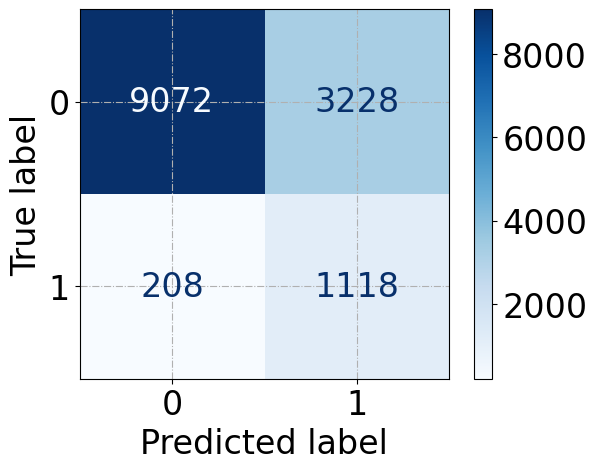

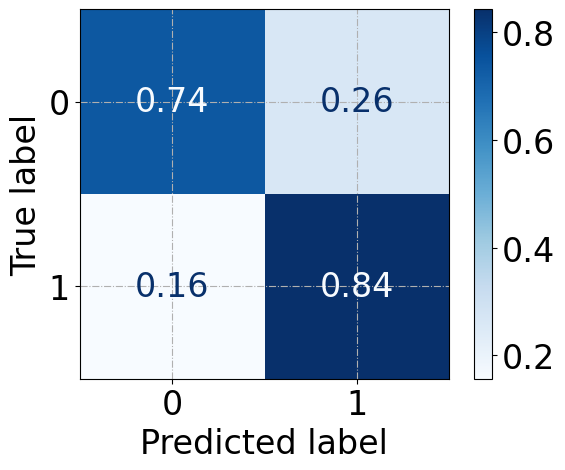

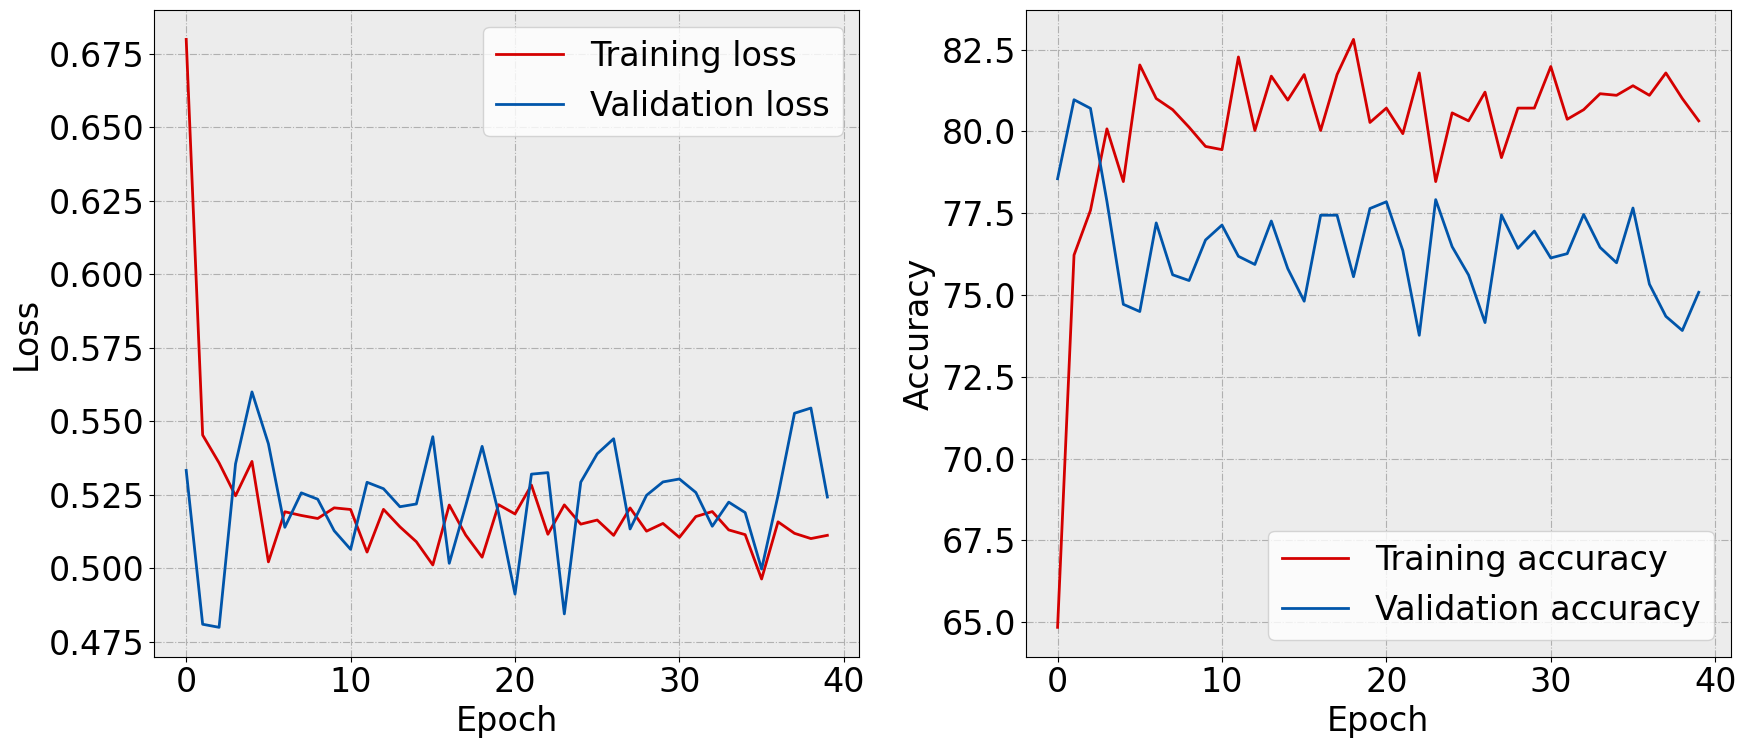

In [48]:
qnn_4, history_4, test_loss_4, test_acc_4 = run_experiment(
        feature_map_name = "fm1",
        ansatz_name = "ansatz1",
        layers = 2,
        n_epochs = 40,
        n_batches = 64,
        batch_size = 32,
        min_learn_rate = 1e-3,
        max_learn_rate = 1e-1)

DataLoader info (batch_size = 64):
  - Train batches: 994
  - Val batches: 213
  - Test batches: 213

Model: 2 layer(s), angle_shape = (2, 5)

Training Configuration:
  1. Feature map: fm1
  2. Ansatz: ansatz1
  3. Learning rate range: [0.001, 0.1]
  4. Device: cpu
  5. Total train batches available: 994
  6. Batches per epoch: 64
  7. Epochs: 40



Epoch 1/40 [Val]  : 100%|██████████| 213/213 [00:27<00:00,  7.74it/s]


Epoch 1/40: Train Loss = 0.6851, Train Acc = 66.24% | Val Loss = 0.5425, Val Acc = 79.06%


Epoch 2/40 [Val]  : 100%|██████████| 213/213 [00:27<00:00,  7.69it/s]


Epoch 2/40: Train Loss = 0.5372, Train Acc = 77.05% | Val Loss = 0.5126, Val Acc = 80.12%


...

Epoch 39/40: Train Loss = 0.5104, Train Acc = 81.15% | Val Loss = 0.5242, Val Acc = 77.03%


Epoch 40/40 [Val]  : 100%|██████████| 213/213 [00:27<00:00,  7.69it/s]


Epoch 40/40: Train Loss = 0.5124, Train Acc = 81.84% | Val Loss = 0.5283, Val Acc = 76.35%

TESTING PHASE


Testing: 100%|██████████| 213/213 [00:28<00:00,  7.54it/s]



Test Loss: 0.5311
Test Accuracy: 0.7613 (76.13%)

Classification Report:
               precision    recall  f1-score   support

Not Hazardous       0.98      0.75      0.85     12300
    Hazardous       0.27      0.88      0.42      1326

     accuracy                           0.76     13626
    macro avg       0.63      0.81      0.63     13626
 weighted avg       0.91      0.76      0.81     13626


Confusion Matrix:
[[9213 3087]
 [ 165 1161]]
[[74.9  25.1 ]
 [12.44 87.56]]


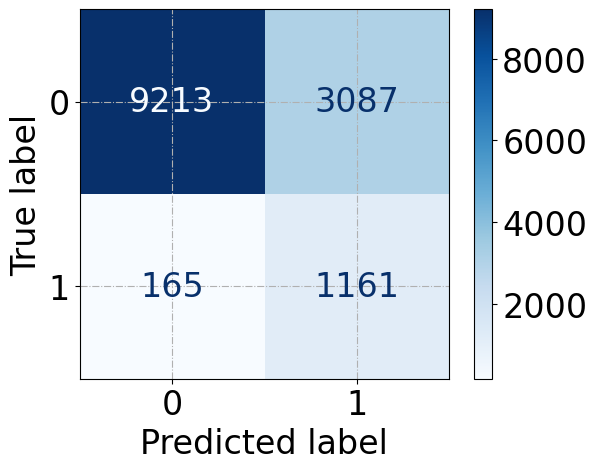

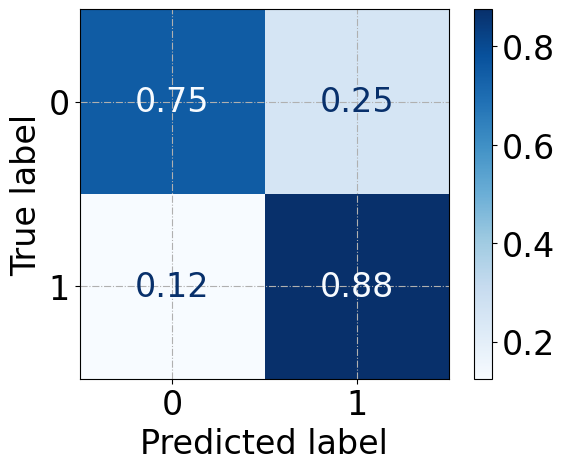

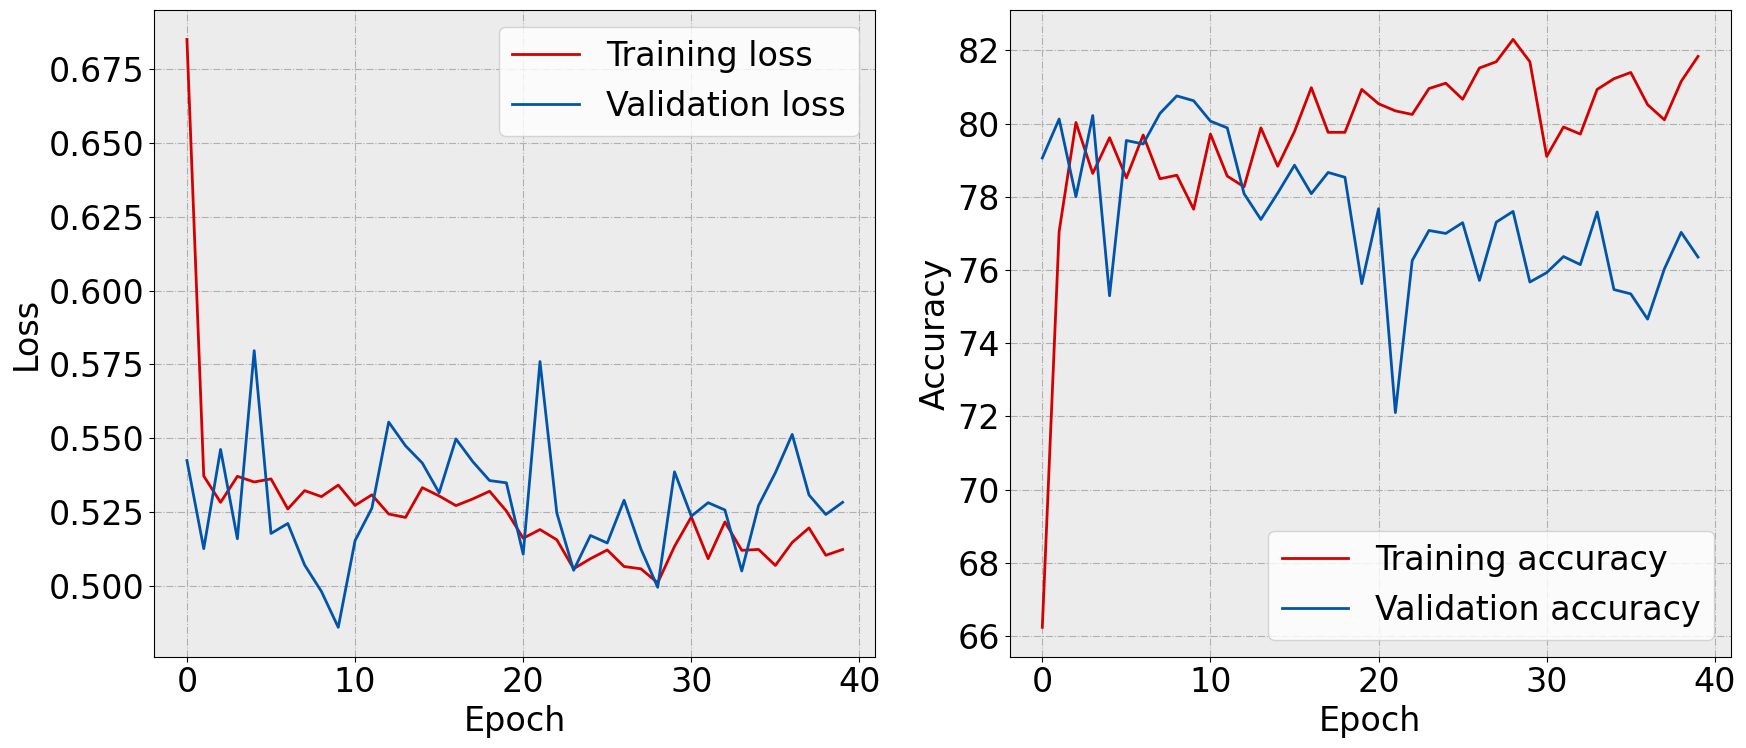

In [46]:
qnn_4, history_4, test_loss_4, test_acc_4 = run_experiment(
        feature_map_name = "fm1",
        ansatz_name = "ansatz1",
        layers = 2,
        n_epochs = 40,
        n_batches = 64,
        batch_size = 64,
        min_learn_rate = 1e-3,
        max_learn_rate = 1e-1)

DataLoader info (batch_size = 128):
  - Train batches: 497
  - Val batches: 107
  - Test batches: 107

Model: 2 layer(s), angle_shape = (2, 5)

Training Configuration:
  1. Feature map: fm1
  2. Ansatz: ansatz1
  3. Learning rate range: [0.001, 0.1]
  4. Device: cpu
  5. Total train batches available: 497
  6. Batches per epoch: 64
  7. Epochs: 40



Epoch 1/40 [Val]  : 100%|██████████| 107/107 [00:27<00:00,  3.87it/s]


Epoch 1/40: Train Loss = 0.6768, Train Acc = 65.86% | Val Loss = 0.5020, Val Acc = 80.63%


Epoch 2/40 [Val]  : 100%|██████████| 107/107 [00:26<00:00,  3.98it/s]


Epoch 2/40: Train Loss = 0.5352, Train Acc = 78.70% | Val Loss = 0.5099, Val Acc = 80.47%


...

Epoch 39/40: Train Loss = 0.5223, Train Acc = 79.52% | Val Loss = 0.5166, Val Acc = 77.30%


Epoch 40/40 [Val]  : 100%|██████████| 107/107 [00:33<00:00,  3.24it/s]


Epoch 40/40: Train Loss = 0.5073, Train Acc = 81.67% | Val Loss = 0.5267, Val Acc = 75.33%

TESTING PHASE


Testing: 100%|██████████| 107/107 [00:30<00:00,  3.46it/s]



Test Loss: 0.5293
Test Accuracy: 0.7507 (75.07%)

Classification Report:
               precision    recall  f1-score   support

Not Hazardous       0.98      0.74      0.84     12300
    Hazardous       0.26      0.85      0.40      1326

     accuracy                           0.75     13626
    macro avg       0.62      0.80      0.62     13626
 weighted avg       0.91      0.75      0.80     13626


Confusion Matrix:
[[9096 3204]
 [ 193 1133]]
[[73.95 26.05]
 [14.56 85.44]]


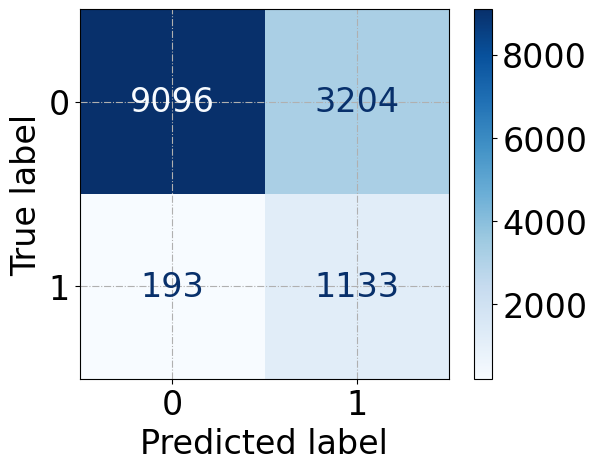

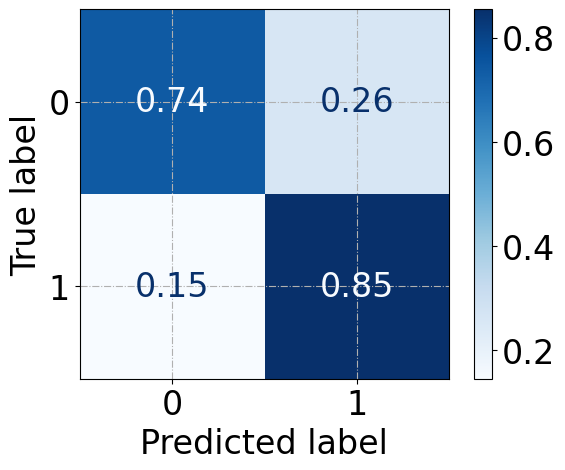

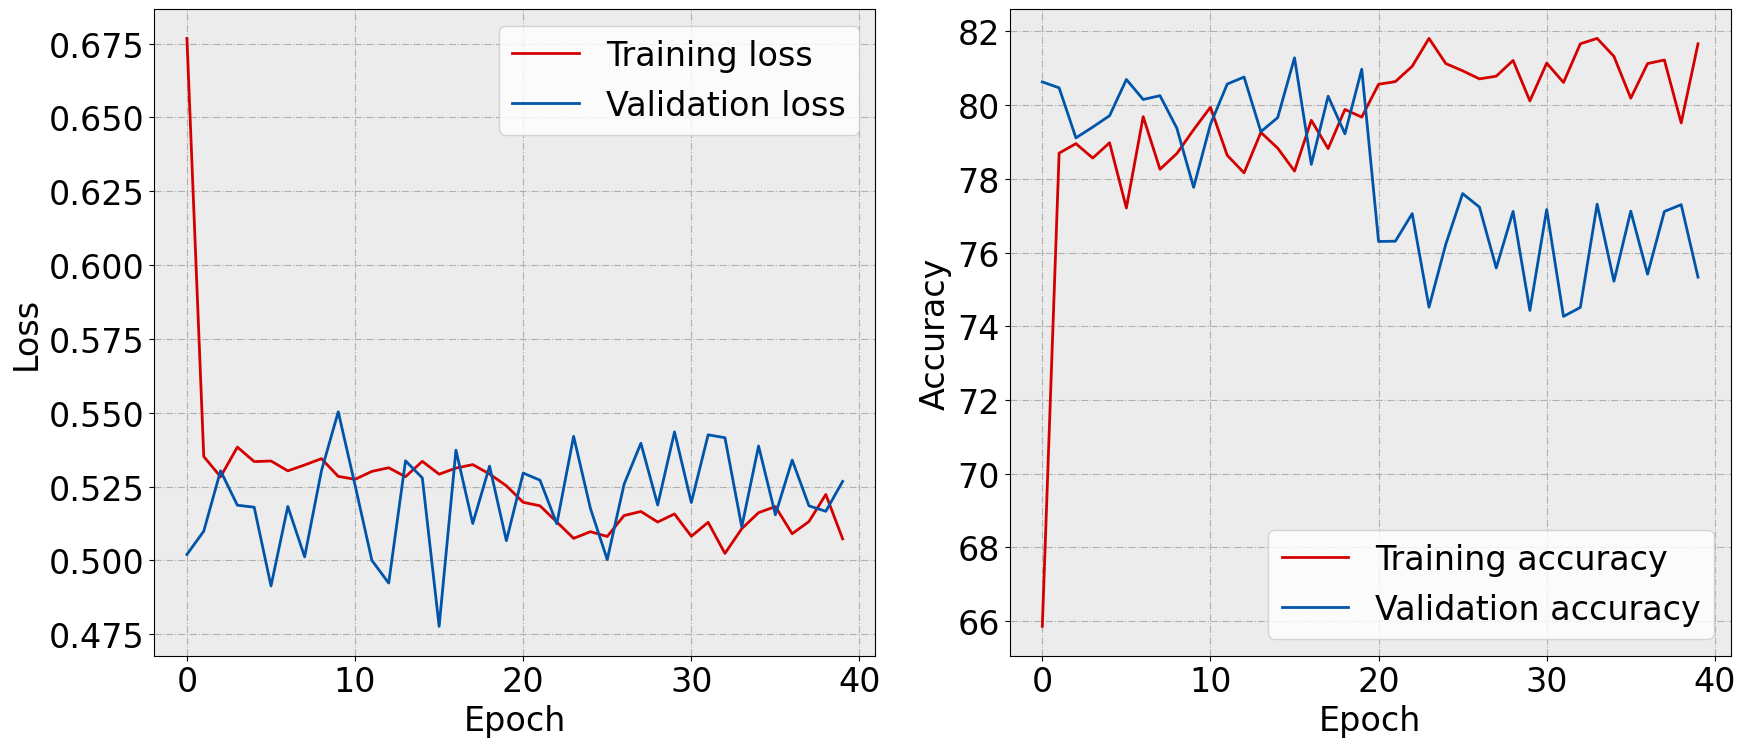

In [ ]:
qnn_4, history_4, test_loss_4, test_acc_4 = run_experiment(
        feature_map_name = "fm1",
        ansatz_name = "ansatz1",
        layers = 2,
        n_epochs = 40,
        n_batches = 64,
        batch_size = 128,
        min_learn_rate = 1e-3,
        max_learn_rate = 1e-1)

41m 15.6s